# Delta-V Perturbation Analysis

This notebook analyzes the **Delta-V model**: a small additive network `delta_V_net` trained
on top of a frozen base model to capture the perturbation potential directly.

**Architecture**: `V_total(cos_q, sin_q) = V_net_frozen(cos_q, sin_q) + delta_V_net(cos_q, sin_q)`

Only `delta_V_net` is trainable — encoder, decoder, V_net, M_net, g_net are all hard-frozen.
This gives us a **clean, direct signal** for the perturbation, without the subtraction noise
that plagued the V_pert − V_unpert approach in notebook 4.

| Quantity | Notebook 4 (subtraction) | This notebook (Delta-V) |
|----------|--------------------------|-------------------------|
| ΔV | V_pert(φ) − V_unpert(φ) | delta_V_net(cos_q, sin_q) directly |
| Δa | a_pert(φ) − a_unpert(φ) | −(1/M) · d(delta_V)/dφ |
| Noise | High (two independent NNs) | Low (single small network) |

In [101]:
# Standard library imports
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

# Auto-detect project root
_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pytorch_lightning import seed_everything
from pysr import PySRRegressor

# Import BOTH model classes
from examples.pend_lag_cavae_trainer import Model  # original (unperturbed)
from examples.pend_delta_v_frozen_trainer import DeltaVFrozenModel  # delta-V

seed_everything(0)
%matplotlib inline

Project root: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main


## Configuration

In [102]:
# ============================================================
# CONFIGURATION
# ============================================================

# Checkpoints
CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
CKPT_DELTA_V     = '_ckpt_epoch_290.ckpt'

# ============================================================
# PERTURBATION CONFIG — change ONLY this block to switch tests
# ============================================================
# Uncomment ONE of the following configs:

# # --- Pure cubic (η₃ = 0.1125) ---
# perturbation_config = dict(
#     name        = "Pure cubic (eta3=0.1125)",
#     da_formula  = "-0.3375 * theta^3",
#     dV_formula  = "M * 0.3375/4 * theta^4",
#     true_da     = lambda theta, M: -0.3375 * theta**3,
#     true_dV_raw = lambda theta, M: M * 0.3375 / 4 * theta**4,
#     pysr_unary      = [],
#     pysr_binary     = ['+', '-', '*'],
#     sindy_library   = lambda ps: ps.PolynomialLibrary(degree=5, include_bias=True),
#     sindy_library_v = lambda ps: ps.PolynomialLibrary(degree=6, include_bias=True),
#     poly_deg_da = 3,
#     poly_deg_dV = 4,
# )

# --- T1: sin(2*theta), B=2.0 ---
perturbation_config = dict(
    name        = "T1: sin(2*theta), B=2.0",
    da_formula  = "2.0 * sin(2*theta)",
    dV_formula  = "M * 1.0 * cos(2*theta)",
    true_da     = lambda theta, M: 2.0 * np.sin(2 * theta),
    true_dV_raw = lambda theta, M: M * 2.0 / 2 * np.cos(2 * theta),
    pysr_unary      = ['sin', 'cos'],
    pysr_binary     = ['+', '-', '*'],
    sindy_library   = lambda ps: ps.PolynomialLibrary(degree=5, include_bias=True) + ps.FourierLibrary(n_frequencies=3),
    sindy_library_v = lambda ps: ps.PolynomialLibrary(degree=6, include_bias=True) + ps.FourierLibrary(n_frequencies=3),
    poly_deg_da = 5,
    poly_deg_dV = 6,
)

# # --- T2: cos(theta), B=1.5 ---
# perturbation_config = dict(
#     name        = "T2: cos(theta), B=1.5",
#     da_formula  = "1.5 * cos(theta)",
#     dV_formula  = "-M * 1.5 * sin(theta)",
#     true_da     = lambda theta, M: 1.5 * np.cos(theta),
#     true_dV_raw = lambda theta, M: -M * 1.5 * np.sin(theta),
#     pysr_unary      = ['sin', 'cos'],
#     pysr_binary     = ['+', '-', '*'],
#     sindy_library   = lambda ps: ps.PolynomialLibrary(degree=5, include_bias=True) + ps.FourierLibrary(n_frequencies=3),
#     sindy_library_v = lambda ps: ps.PolynomialLibrary(degree=6, include_bias=True) + ps.FourierLibrary(n_frequencies=3),
#     poly_deg_da = 5,
#     poly_deg_dV = 6,
# )

# Short alias
PC = perturbation_config

# Sampling
N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi

# PySR hyperparameters
PYSR_NITERATIONS = 100
PYSR_MAXSIZE     = 25

# Plot settings
DPI = 600

print(f"Perturbation: {PC['name']}")
print(f"  da = {PC['da_formula']}")
print(f"  dV = {PC['dV_formula']}")

Perturbation: T1: sin(2*theta), B=2.0
  da = 2.0 * sin(2*theta)
  dV = M * 1.0 * cos(2*theta)


## 1. Load Models

Load the unperturbed base model (for phase offset calibration) and the Delta-V model.

In [103]:
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

# Load unperturbed model (for calibration)
model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()
print("Unperturbed model loaded.")

# Load Delta-V model — need weights_only=False for old PL checkpoints
# PyTorch 2.6+ changed default weights_only from False to True
import pytorch_lightning as pl
_orig_torch_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_load

model_delta_v = DeltaVFrozenModel.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_DELTA_V), map_location='cpu')
model_delta_v.eval()

torch.load = _orig_torch_load  # restore original

# Verify delta_V_net exists and has trained weights
print(f"Delta-V model loaded.")
n_params = sum(p.numel() for p in model_delta_v.ode.delta_V_net.parameters())
print(f"  delta_V_net parameters: {n_params}")

Unperturbed model loaded.
Delta-V model loaded.
  delta_V_net parameters: 2751


## 2. Helper Functions

In [104]:
def extract_physics(model, theta_np):
    """Extract V(φ), M(φ), dV/dφ, and acceleration a(φ) from a trained model."""
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV_dtheta = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV_dtheta
    
    return {
        'theta': theta_np,
        'V':         V.detach().numpy().flatten(),
        'M':         M.detach().numpy().flatten(),
        'dVdtheta':  dV_dtheta.detach().numpy().flatten(),
        'acc':       acc.detach().numpy().flatten(),
    }


def extract_delta_v_physics(model, theta_np):
    """
    Extract delta_V_net output and its derived quantities.
    
    Returns delta_V(φ), d(delta_V)/dφ, and delta_a(φ) = -(1/M) * d(delta_V)/dφ.
    The M used is the frozen M_net from the same model.
    """
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    
    # All network outputs
    delta_V = model.ode.delta_V_net(cos_sin)
    V_base = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    M_flat = M.squeeze()
    V_total = V_base + delta_V

    # Compute gradients — use retain_graph=True on first call
    # since delta_V and V_base share the same graph through cos_sin
    dV_total_dtheta = torch.autograd.grad(
        V_total.sum(), theta, retain_graph=True, create_graph=False
    )[0]
    d_delta_V_dtheta = torch.autograd.grad(
        delta_V.sum(), theta, create_graph=False
    )[0]

    delta_acc = -(1.0 / M_flat) * d_delta_V_dtheta
    total_acc = -(1.0 / M_flat) * dV_total_dtheta
    
    return {
        'theta':          theta_np,
        'delta_V':        delta_V.detach().numpy().flatten(),
        'd_delta_V':      d_delta_V_dtheta.detach().numpy().flatten(),
        'delta_acc':      delta_acc.detach().numpy().flatten(),
        'V_base':         V_base.detach().numpy().flatten(),
        'V_total':        V_total.detach().numpy().flatten(),
        'total_acc':      total_acc.detach().numpy().flatten(),
        'M':              M_flat.detach().numpy().flatten(),
    }


def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    """Find phase offset between NN angle φ and physical angle θ_phys."""
    K = 3 * g / (2 * l)
    
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead'
            )
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    
    mse, sign, offset = best
    res_free = minimize(
        lambda p: np.mean((a_unpert - (p[0] * np.sin(sign * (phi + offset))))**2),
        [-K], method='Nelder-Mead'
    )
    amp_fitted = res_free.x[0]
    
    return {
        'offset': offset, 'sign': sign, 'amplitude': amp_fitted,
        'mse': mse, 'expected_amplitude': -K,
    }


def phi_to_theta_phys(phi, calib):
    """Convert NN angle φ to physical angle θ_phys ∈ [-π, π]."""
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi


def run_pysr(X, y, niterations=100, maxsize=20, parsimony=0.005,
             binary_operators=['+', '-', '*'],
             unary_operators=['sin', 'cos'],
             variable_name='theta'):
    """Run PySR symbolic regression. Returns (model, best_idx, expr, pred)."""
    sr = PySRRegressor(
        niterations=niterations,
        binary_operators=binary_operators,
        unary_operators=unary_operators,
        denoise=False,
        model_selection='best',
        maxsize=maxsize,
        parsimony=parsimony,
        populations=30,
        population_size=50,
        ncycles_per_iteration=550,
        weight_optimize=0.001,
        adaptive_parsimony_scaling=1000,
        random_state=42,
        procs=4,
        temp_equation_file=True,
    )
    sr.fit(X, y, variable_names=[variable_name])
    
    eqs = sr.equations_
    scores = eqs['score'].values.astype(float)
    best_idx = eqs.index[np.argmax(scores)]
    
    expr = sr.sympy(index=best_idx)
    pred = sr.predict(X, index=best_idx)
    print(f"  Selected complexity {eqs['complexity'].values[np.argmax(scores)]:.0f} (max score)")
    print(f"  Expression: {expr}")
    return sr, best_idx, expr, pred


print("Helper functions defined.")

Helper functions defined.


## 3. Extract Physics & Calibrate Phase Offset

Use the unperturbed model to calibrate the phase offset, then extract
delta_V_net quantities in physical coordinates.

In [105]:
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

# Extract base physics from unperturbed model (for calibration)
phys_unpert = extract_physics(model_unpert, theta_range)

# Calibrate phase offset
calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print("Phase offset calibration:")
print(f"  sign    = {calib['sign']:+.0f}")
print(f"  offset  = {calib['offset']:.4f} rad ({np.degrees(calib['offset']):.1f} deg)")
print(f"  amplitude (fitted) = {calib['amplitude']:.2f}")
print(f"  amplitude (expected) = {calib['expected_amplitude']:.2f}")
print(f"  MSE = {calib['mse']:.4f}")

# Convert to physical coordinates
theta_phys = phi_to_theta_phys(theta_range, calib)
sort_idx = np.argsort(theta_phys)
theta_phys_sorted = theta_phys[sort_idx]
theta_gt = theta_phys_sorted  # standard alias

# Extract delta-V physics
delta_v_phys = extract_delta_v_physics(model_delta_v, theta_range)

# Sort everything to physical coordinates
delta_V_sorted     = delta_v_phys['delta_V'][sort_idx]
delta_V_sorted     = delta_V_sorted - delta_V_sorted[0]  # zero-anchor
delta_acc_sorted   = delta_v_phys['delta_acc'][sort_idx]
d_delta_V_sorted   = delta_v_phys['d_delta_V'][sort_idx]
V_base_sorted      = delta_v_phys['V_base'][sort_idx]
V_total_sorted     = delta_v_phys['V_total'][sort_idx]
total_acc_sorted   = delta_v_phys['total_acc'][sort_idx]
M_sorted           = delta_v_phys['M'][sort_idx]
a_unpert_sorted    = phys_unpert['acc'][sort_idx]

# M_scale: mean of learned mass matrix (needed for ground truth)
M_scale = np.mean(M_sorted)

# Ground truth from config (GENERIC — no hardcoded formulas)
true_delta_a     = PC['true_da'](theta_gt, M_scale)
true_delta_V_raw = PC['true_dV_raw'](theta_gt, M_scale)
true_delta_V     = true_delta_V_raw - true_delta_V_raw[0]  # zero-anchored

print(f"\nM_scale (mean of learned M_net): {M_scale:.4f}")
print(f"Delta-V range: [{delta_V_sorted.min():.4f}, {delta_V_sorted.max():.4f}]")
print(f"Delta-a range: [{delta_acc_sorted.min():.4f}, {delta_acc_sorted.max():.4f}]")

Phase offset calibration:
  sign    = +1
  offset  = 2.2050 rad (126.3 deg)
  amplitude (fitted) = -15.45
  amplitude (expected) = -15.00
  MSE = 0.6618

M_scale (mean of learned M_net): 0.6915
Delta-V range: [-2.2156, 0.2558]
Delta-a range: [-2.9059, 3.4729]


## 4. Overview: Delta-V Network Output vs Ground Truth

Direct comparison of what delta_V_net learned vs. the true perturbation.

In [106]:
# Ground truth already computed in cell above via PC config
from sklearn.metrics import r2_score

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=DPI)

# --- Top left: Delta-V (perturbation potential) ---
ax = axes[0, 0]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential: delta_V_net vs Ground Truth')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Top right: Delta-a (perturbation acceleration) ---
ax = axes[0, 1]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration: Delta-V derived vs Ground Truth')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottom left: Total V ---
ax = axes[1, 0]
V_unpert_sorted = phys_unpert['V'].flatten()[sort_idx]
ax.plot(theta_gt, V_unpert_sorted, 'g-', lw=2, label='V_net (unperturbed model)')
ax.plot(theta_gt, V_base_sorted, 'b--', lw=1.5, label='V_net (frozen, in delta-V model)')
ax.plot(theta_gt, V_total_sorted, 'r-', lw=2, label='V_total = V_net + delta_V_net')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel('V', fontsize=14)
ax.set_title('Potential Energy Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottom right: Total acceleration ---
ax = axes[1, 1]
a_true_base = -15.0 * np.sin(theta_gt)
a_true_total = a_true_base + true_delta_a
ax.plot(theta_gt, a_unpert_sorted, 'g-', lw=2, label='a (unperturbed NN)')
ax.plot(theta_gt, total_acc_sorted, 'b-', lw=2, label='a_total (delta-V model)')
ax.plot(theta_gt, a_true_total, 'r--', lw=2, label='True a_total (ground truth)')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel('a', fontsize=14)
ax.set_title('Total Acceleration Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

r2_dv = r2_score(true_delta_V, delta_V_sorted)
r2_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"R2 (delta_V_net vs true dV): {r2_dv:.4f}")
print(f"R2 (delta_a vs true da):     {r2_da:.4f}")

R2 (delta_V_net vs true dV): -0.5401
R2 (delta_a vs true da):     0.4903


In [107]:
# Extended range for full picture
phi_ext = np.linspace(-2*np.pi, 2*np.pi, 1000)
phys_unpert_ext = extract_physics(model_unpert, phi_ext)
dv_phys_ext = extract_delta_v_physics(model_delta_v, phi_ext)

# Convert to theta_phys using same calibration
theta_phys_ext_unwrapped = calib['sign'] * (phi_ext + calib['offset'])
theta_center = calib['sign'] * calib['offset']
theta_phys_ext_unwrapped = theta_phys_ext_unwrapped - np.round(theta_center / (2*np.pi)) * 2*np.pi
sort_ext = np.argsort(theta_phys_ext_unwrapped)
theta_ext_sorted = theta_phys_ext_unwrapped[sort_ext]

# Build "perturbed" dict from delta-V model for consistent plotting
phys_pert_ext = {
    'V':   dv_phys_ext['V_total'],
    'M':   dv_phys_ext['M'],
    'acc': dv_phys_ext['total_acc'],
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=DPI)

labels = ['Unperturbed', 'Delta-V (V_total)']
colors = ['#377eb8', '#e41a1c']
data_ext = [phys_unpert_ext, phys_pert_ext]

# Row 1: Raw V, M, acc on extended range
for i, (key, ylabel, title) in enumerate([
    ('V',   r'$V(\theta_{\mathrm{phys}})$',          'Potential Energy'),
    ('M',   r'$M(\theta_{\mathrm{phys}})$',          'Mass Matrix'),
    ('acc', r'$\ddot{\theta}$',  r'Acceleration ($\dot{\theta}=0$)'),
]):
    for d, label, c in zip(data_ext, labels, colors):
        axes[0, i].plot(theta_ext_sorted, d[key][sort_ext], color=c, lw=2, label=label, alpha=0.8)
    axes[0, i].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
    axes[0, i].set_ylabel(ylabel, fontsize=14)
    axes[0, i].set_title(title, fontsize=13)
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].set_xlim(-1.5*np.pi, 1.5*np.pi)

# Row 2: Perturbation signals on [-pi, pi]
ax = axes[1, 0]
ax.plot(theta_gt, delta_V_sorted, 'purple', lw=2, label=r'$\Delta V$ (delta_V_net)')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential (delta_V_net)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
M_unpert_sorted = phys_unpert['M'].flatten()[sort_idx]
M_dv_sorted = delta_v_phys['M'][sort_idx]
M_diff = M_dv_sorted - M_unpert_sorted
ax.plot(theta_gt, M_diff, 'purple', lw=2)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M$', fontsize=14)
ax.set_title('Mass Difference (should be ~0, M frozen)', fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(theta_gt, delta_acc_sorted, 'purple', lw=2, label=r'$\Delta a$ (delta_V_net)')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration (from delta_V_net)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Row 1: Unperturbed vs Delta-V total (V_base + delta_V_net)")
print("Row 2: delta_V_net output directly (not subtraction of two models)")

Row 1: Unperturbed vs Delta-V total (V_base + delta_V_net)
Row 2: delta_V_net output directly (not subtraction of two models)


## 5. Polynomial Regression on Delta-V Signal

Since delta_V_net directly outputs the perturbation, polynomial regression
should work much better than on the noisy V_pert − V_unpert subtraction.

In [108]:
from numpy.polynomial import polynomial as P

print("=" * 60)
print(f"POLYNOMIAL REGRESSION — {PC['name']}")
print("=" * 60)

# --- Fit delta_a(theta) ---
print(f"\n--- Polynomial fit to delta_a ---")
print(f"True: da = {PC['da_formula']}")

for deg in range(PC['poly_deg_da'], PC['poly_deg_da'] + 3):
    coeffs = np.polyfit(theta_gt, delta_acc_sorted, deg)
    pred = np.polyval(coeffs, theta_gt)
    r2 = 1 - np.sum((delta_acc_sorted - pred)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)
    print(f"\n  Degree {deg} (R2 = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    theta^{power}: {c:+.6f}")

# --- Fit delta_V(theta) ---
print(f"\n\n--- Polynomial fit to delta_V ---")
print(f"True: dV = {PC['dV_formula']}")

for deg in range(PC['poly_deg_dV'], PC['poly_deg_dV'] + 3):
    coeffs = np.polyfit(theta_gt, delta_V_sorted, deg)
    pred = np.polyval(coeffs, theta_gt)
    r2 = 1 - np.sum((delta_V_sorted - pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)
    print(f"\n  Degree {deg} (R2 = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    theta^{power}: {c:+.6f}")

POLYNOMIAL REGRESSION — T1: sin(2*theta), B=2.0

--- Polynomial fit to delta_a ---
True: da = 2.0 * sin(2*theta)

  Degree 5 (R2 = 0.934927):
    theta^5: +0.097737
    theta^4: +0.004627
    theta^3: -1.203258
    theta^2: +0.265762
    theta^1: +2.747191
    theta^0: -0.990818

  Degree 6 (R2 = 0.936083):
    theta^6: -0.003184
    theta^5: +0.097770
    theta^4: +0.047482
    theta^3: -1.203564
    theta^2: +0.124727
    theta^1: +2.747662
    theta^0: -0.924525

  Degree 7 (R2 = 0.952802):
    theta^7: -0.007687
    theta^6: -0.003112
    theta^5: +0.220288
    theta^4: +0.046633
    theta^3: -1.753025
    theta^2: +0.127245
    theta^1: +3.350177
    theta^0: -0.925516


--- Polynomial fit to delta_V ---
True: dV = M * 1.0 * cos(2*theta)

  Degree 6 (R2 = 0.995611):
    theta^6: -0.012958
    theta^5: -0.001967
    theta^4: +0.230477
    theta^3: -0.046272
    theta^2: -1.015170
    theta^1: +0.636263
    theta^0: -0.076256

  Degree 7 (R2 = 0.995675):
    theta^7: -0.000215
    t

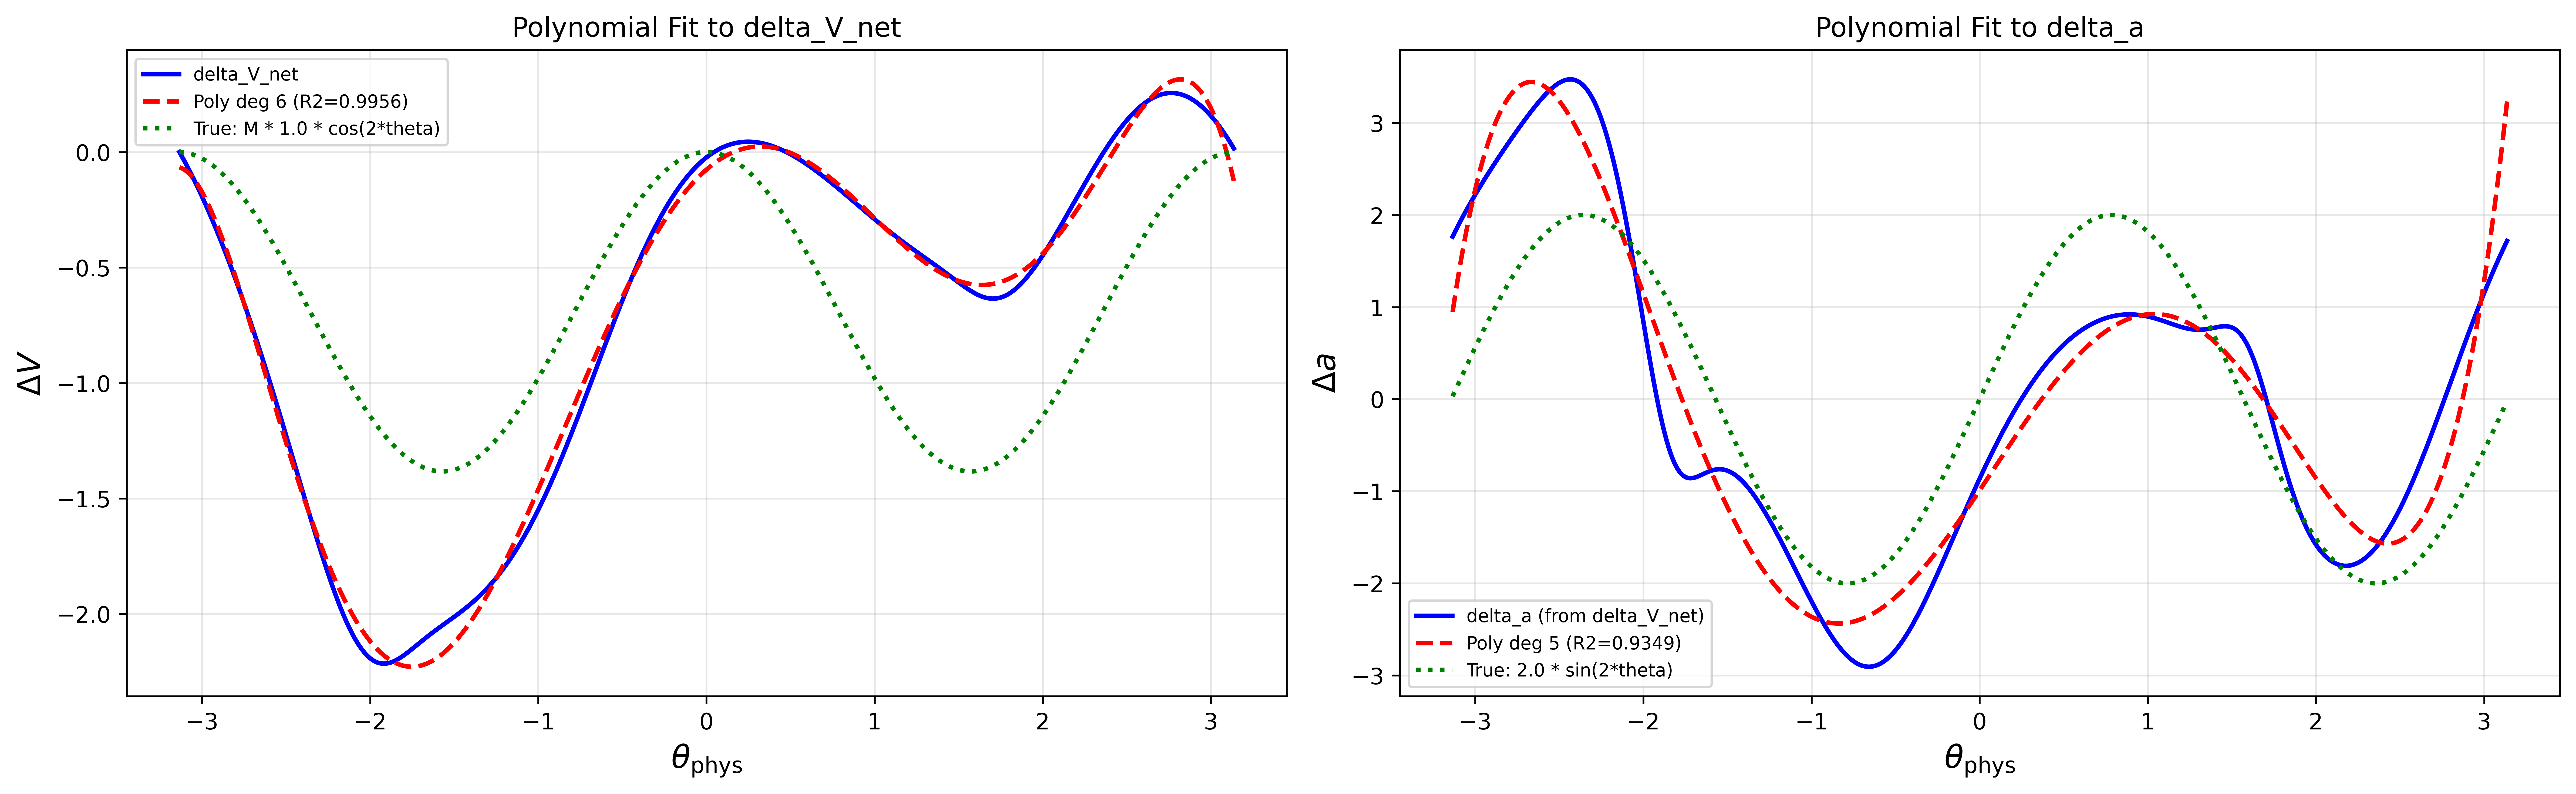

In [109]:
# Plot best polynomial fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# Delta-V
deg_dv = PC['poly_deg_dV']
coeffs_dv = np.polyfit(theta_gt, delta_V_sorted, deg_dv)
poly_dv = np.polyval(coeffs_dv, theta_gt)
r2_dv = 1 - np.sum((delta_V_sorted - poly_dv)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)

ax = axes[0]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, poly_dv, 'r--', lw=2, label=f'Poly deg {deg_dv} (R2={r2_dv:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Polynomial Fit to delta_V_net')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Delta-a
deg_da = PC['poly_deg_da']
coeffs_da = np.polyfit(theta_gt, delta_acc_sorted, deg_da)
poly_da = np.polyval(coeffs_da, theta_gt)
r2_da = 1 - np.sum((delta_acc_sorted - poly_da)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)

ax = axes[1]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, poly_da, 'r--', lw=2, label=f'Poly deg {deg_da} (R2={r2_da:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Polynomial Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SINDy: Sparse Identification of Nonlinear Dynamics

Apply SINDy with polynomial-only library to the Delta-V signal.
Based on notebook 4 findings, we use polynomial-only basis to avoid
poly/trig collinearity issues.

In [110]:
import pysindy as ps

print("=" * 60)
print(f"SINDy — {PC['name']}")
print("=" * 60)

X_sindy = theta_gt.reshape(-1, 1)
thresholds = np.logspace(-3, 0, 20)

# --- SINDy on delta_a ---
print(f"\n--- SINDy on da ---")
print(f"True: da = {PC['da_formula']}")

y_da = delta_acc_sorted.reshape(-1, 1)
lib_da = PC['sindy_library'](ps)

results_da = []
for thr in thresholds:
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    sindy_model = ps.SINDy(feature_library=lib_da, optimizer=optimizer)
    sindy_model.fit(X_sindy, t=1, x_dot=y_da, feature_names=['theta'])
    
    pred = sindy_model.predict(X_sindy)
    ss_res = np.sum((y_da - pred)**2)
    ss_tot = np.sum((y_da - y_da.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    coeffs = sindy_model.coefficients().flatten()
    n_active = np.sum(np.abs(coeffs) > 1e-10)
    
    results_da.append({
        'threshold': thr, 'r2': r2, 'n_active': n_active,
        'coeffs': coeffs, 'model': sindy_model,
        'equations': sindy_model.equations()
    })

candidates = [r for r in results_da if r['n_active'] <= 4 and r['r2'] > 0.5]
best_da = max(candidates if candidates else results_da, key=lambda r: r['r2'])

print(f"\nBest SINDy (da): R2 = {best_da['r2']:.4f}, {best_da['n_active']} active terms")
print(f"  Equation: {best_da['equations']}")
print(f"  Threshold: {best_da['threshold']:.4f}")

# Print all active features
feature_names = best_da['model'].get_feature_names()
print(f"\n  {'Feature':<20} {'Coeff':>12}")
print(f"  {'-'*34}")
for fname, coeff in zip(feature_names, best_da['coeffs']):
    if abs(coeff) > 1e-10:
        print(f"  {fname:<20} {coeff:>12.6f}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(


SINDy — T1: sin(2*theta), B=2.0

--- SINDy on da ---
True: da = 2.0 * sin(2*theta)

Best SINDy (da): R2 = 0.9709, 12 active terms
  Equation: ['-24.564 1 + -1243.364 theta + 10.839 theta^2 + 182.900 theta^3 + -0.571 theta^4 + -5.769 theta^5 + 1302.295 sin(1 theta) + 24.480 cos(1 theta) + -31.133 sin(2 theta) + -0.919 cos(2 theta) + 2.424 sin(3 theta) + -0.109 cos(3 theta)']
  Threshold: 0.0010

  Feature                     Coeff
  ----------------------------------
  1                      -24.564259
  theta                -1243.363914
  theta^2                 10.839340
  theta^3                182.899727
  theta^4                 -0.570821
  theta^5                 -5.769303
  sin(1 theta)          1302.294773
  cos(1 theta)            24.479775
  sin(2 theta)           -31.133109
  cos(2 theta)            -0.919245
  sin(3 theta)             2.424080
  cos(3 theta)            -0.109449


In [111]:
# --- SINDy on delta_V ---
print(f"\n--- SINDy on dV ---")
print(f"True: dV = {PC['dV_formula']}")

y_dv = delta_V_sorted.reshape(-1, 1)
lib_dv = PC['sindy_library_v'](ps)

results_dv = []
for thr in thresholds:
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    sindy_model = ps.SINDy(feature_library=lib_dv, optimizer=optimizer)
    sindy_model.fit(X_sindy, t=1, x_dot=y_dv, feature_names=['theta'])
    
    pred = sindy_model.predict(X_sindy)
    ss_res = np.sum((y_dv - pred)**2)
    ss_tot = np.sum((y_dv - y_dv.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    coeffs = sindy_model.coefficients().flatten()
    n_active = np.sum(np.abs(coeffs) > 1e-10)
    
    results_dv.append({
        'threshold': thr, 'r2': r2, 'n_active': n_active,
        'coeffs': coeffs, 'model': sindy_model,
        'equations': sindy_model.equations()
    })

candidates = [r for r in results_dv if r['n_active'] <= 5 and r['r2'] > 0.5]
best_dv = max(candidates if candidates else results_dv, key=lambda r: r['r2'])

print(f"\nBest SINDy (dV): R2 = {best_dv['r2']:.4f}, {best_dv['n_active']} active terms")
print(f"  Equation: {best_dv['equations']}")
print(f"  Threshold: {best_dv['threshold']:.4f}")

feature_names = best_dv['model'].get_feature_names()
print(f"\n  {'Feature':<20} {'Coeff':>12}")
print(f"  {'-'*34}")
for fname, coeff in zip(feature_names, best_dv['coeffs']):
    if abs(coeff) > 1e-10:
        print(f"  {fname:<20} {coeff:>12.6f}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(



--- SINDy on dV ---
True: dV = M * 1.0 * cos(2*theta)

Best SINDy (dV): R2 = 0.9783, 5 active terms
  Equation: ['-13.131 1 + 5.470 theta^2 + -0.286 theta^4 + 0.836 sin(1 theta) + 13.068 cos(1 theta)']
  Threshold: 0.1624

  Feature                     Coeff
  ----------------------------------
  1                      -13.131168
  theta^2                  5.469601
  theta^4                 -0.285832
  sin(1 theta)             0.836090
  cos(1 theta)            13.068234


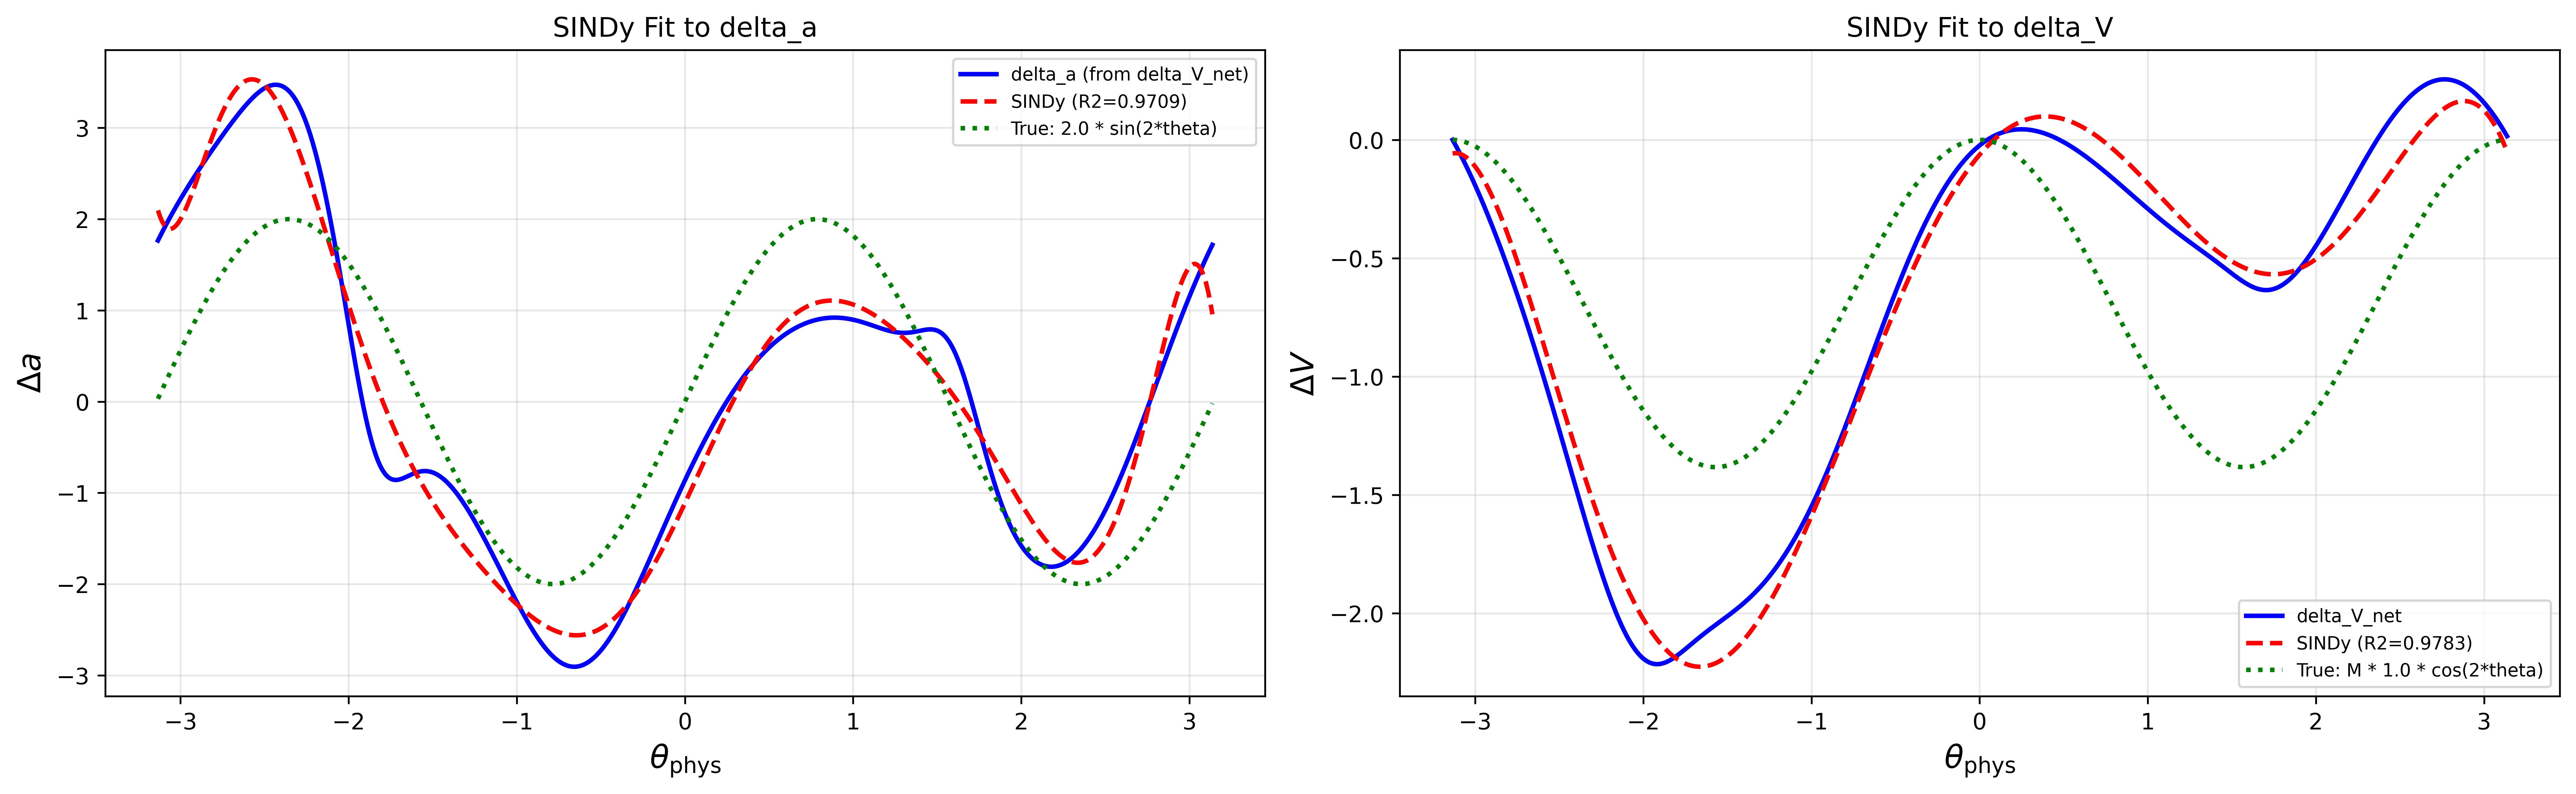

In [112]:
# Plot SINDy fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# da
sindy_pred_da = np.array(best_da['model'].predict(X_sindy)).flatten()
r2_sindy_da = best_da['r2']
ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, sindy_pred_da, 'r--', lw=2, label=f'SINDy (R2={r2_sindy_da:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('SINDy Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# dV
sindy_pred_dv = np.array(best_dv['model'].predict(X_sindy)).flatten()
r2_sindy_dv = best_dv['r2']
ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, sindy_pred_dv, 'r--', lw=2, label=f'SINDy (R2={r2_sindy_dv:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('SINDy Fit to delta_V')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. PySR Symbolic Regression on Delta-V Signal

Apply PySR with polynomial operators to the clean delta_V_net signal.

In [113]:
print("=" * 60)
print(f"PySR — {PC['name']}")
print("=" * 60)

# --- PySR on delta_a ---
print(f"\n--- PySR on da ---")
X_pysr = theta_gt.reshape(-1, 1)

sr_da, idx_da, expr_da, pred_da = run_pysr(
    X_pysr, delta_acc_sorted,
    niterations=PYSR_NITERATIONS,
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    binary_operators=PC['pysr_binary'],
    unary_operators=PC['pysr_unary'],
    variable_name='theta',
)

PySR — T1: sin(2*theta), B=2.0

--- PySR on da ---


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.900e+05
Progress: 644 / 3000 total iterations (21.467%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.984e+00  0.000e+00  y = -0.028409
3           2.692e+00  5.144e-02  y = theta * -0.29811
4           1.470e+00  6.048e-01  y = sin(theta * 1.9027)
6           9.959e-01  1.948e-01  y = sin(theta * 1.9381) * 1.9628
7           7.678e-01  2.602e-01  y = sin(theta * 1.9026) - cos(theta)
9           2.911e-01  4.848e-01  y = (sin(theta * 1.9381) * 1.9651) - cos(theta)
11          2.498e-01  7.665e-02  y = (sin(theta + (theta + 0.18198)) * 2.0153) - cos(theta)
13          1.989e-01  1.139e-01  y = (cos(theta) * -1.242) + (sin((theta * 1.9328) + 0.1944...
                                      8) * 2.0002)
17          1.978e-01  1.406e-03  y = (cos

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 3.790e+05
Progress: 2338 / 3000 total iterations (77.933%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.984e+00  0.000e+00  y = -0.028409
3           2.692e+00  5.144e-02  y = theta * -0.29811
4           1.470e+00  6.048e-01  y = sin(theta * 1.9027)
6           9.959e-01  1.948e-01  y = sin(theta * 1.9381) * 1.9628
7           7.678e-01  2.602e-01  y = sin(theta * 1.9026) - cos(theta)
9           2.911e-01  4.848e-01  y = (sin(theta * 1.9381) * 1.9651) - cos(theta)
11          2.272e-01  1.241e-01  y = (sin((theta + 0.094084) * 1.943) * 2.0001) - cos(theta...
                                      )
13          1.989e-01  6.650e-02  y = (cos(theta) * -1.242) + (sin((theta * 1.9328) + 0.1944...
                                      8) * 2.0002

In [114]:
# --- PySR on delta_V ---
print(f"\n--- PySR on dV ---")

sr_dv, idx_dv, expr_dv, pred_dv = run_pysr(
    X_pysr, delta_V_sorted,
    niterations=PYSR_NITERATIONS,
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    binary_operators=PC['pysr_binary'],
    unary_operators=PC['pysr_unary'],
    variable_name='theta',
)


--- PySR on dV ---


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.450e+05
Progress: 526 / 3000 total iterations (17.533%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.016e-01  0.000e+00  y = -0.70484
4           2.663e-01  2.716e-01  y = sin(theta) + -0.70634
5           2.521e-01  5.489e-02  y = sin(sin(theta)) + -0.70618
6           1.390e-01  5.953e-01  y = sin(theta) - cos(cos(theta))
7           6.920e-02  6.976e-01  y = sin(theta + cos(theta)) - 1.1459
9           1.818e-02  6.682e-01  y = (sin(theta) * (sin(theta) + -0.59773)) * -1.3981
10          1.596e-02  1.305e-01  y = ((sin(theta) * -1.6121) + 0.9508) * sin(sin(theta))
11          8.604e-03  6.178e-01  y = ((sin(theta) + -0.58838) * -1.3821) * sin(theta * 0.92...
                                      641)
12          6.828e-03  2.312e-01  y =

[ Info: Final population:
[ Info: Results saved to:


  Selected complexity 7 (max score)
  Expression: sin(theta + cos(theta)) - 1*1.14591
  - /var/folders/5x/4lk3vhs53hq_qw_z1p9yk48m0000gn/T/tmpooxj7knd/20260302_102228_TpKOHB/hall_of_fame.csv


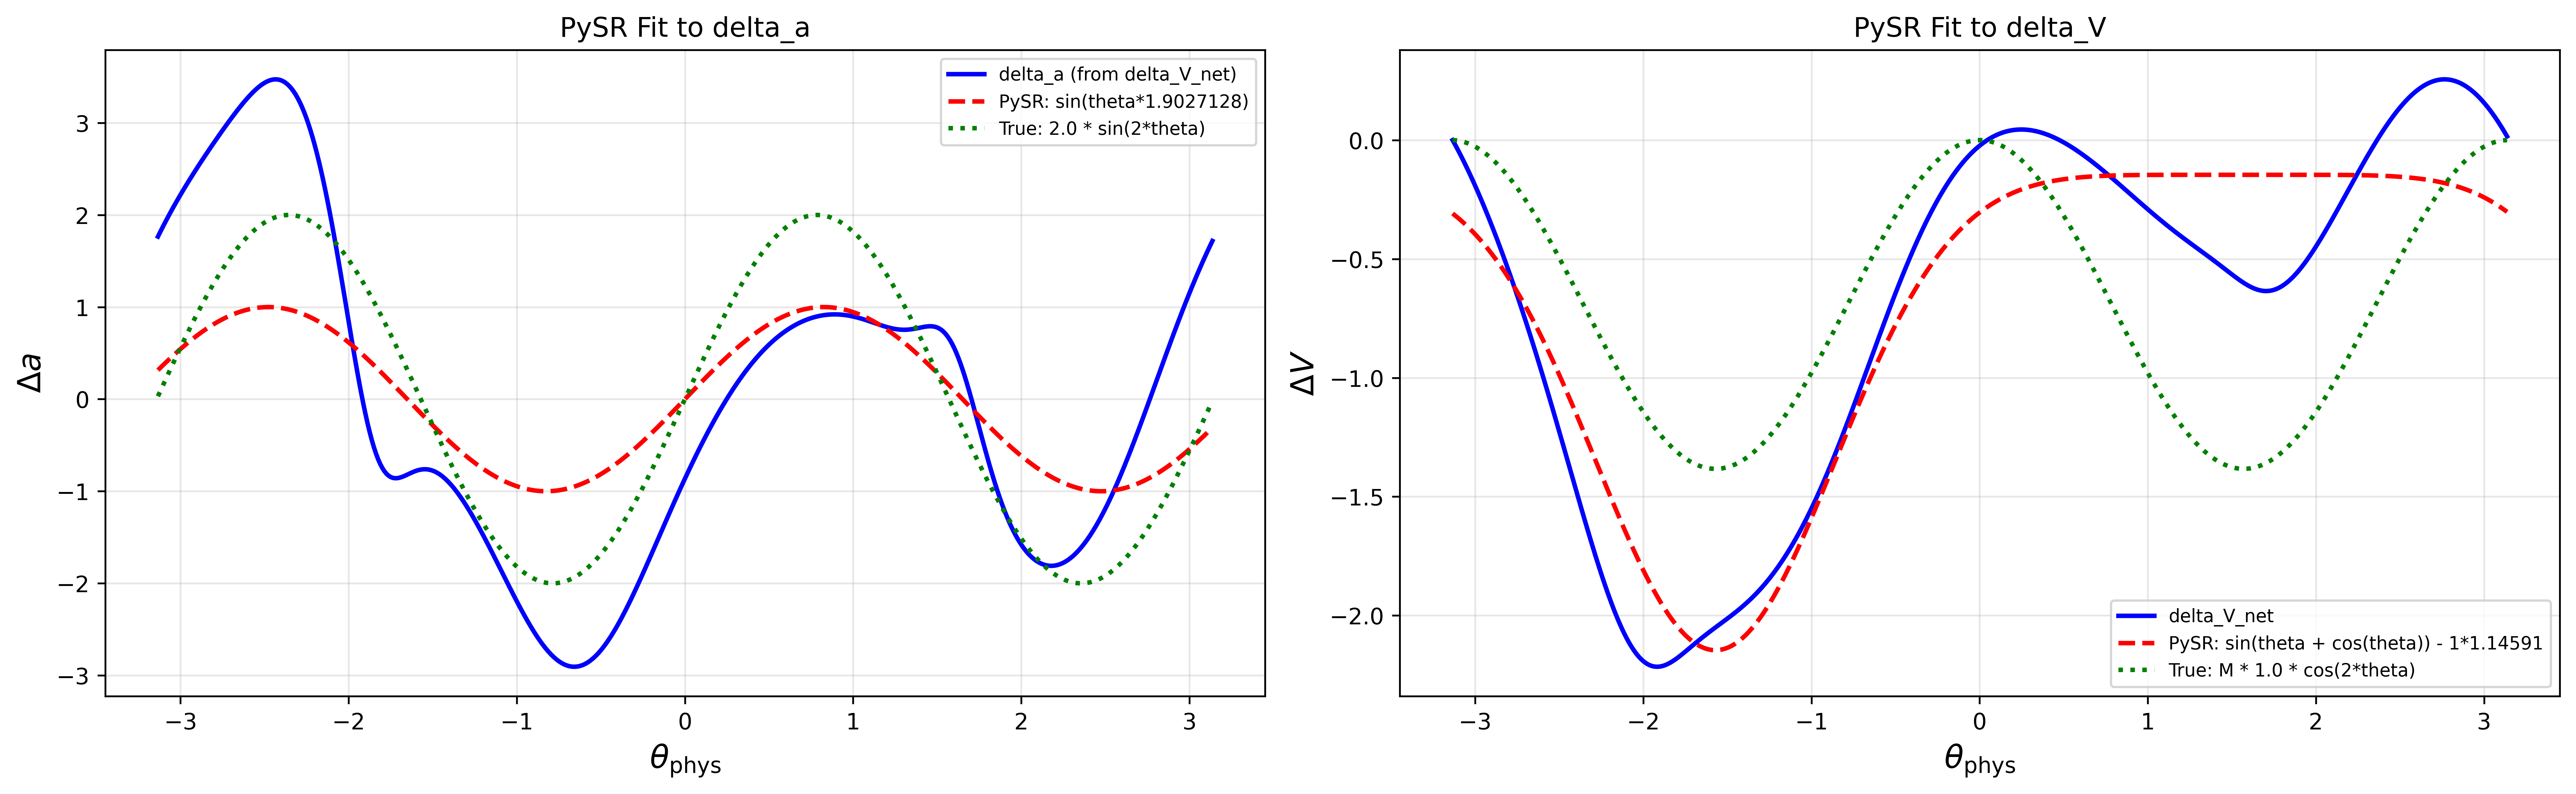

In [115]:
# Plot PySR fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, pred_da, 'r--', lw=2, label=f'PySR: {expr_da}')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('PySR Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, pred_dv, 'r--', lw=2, label=f'PySR: {expr_dv}')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('PySR Fit to delta_V')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Expand PySR Expressions to Polynomial Form

Extract polynomial coefficients from PySR expressions for direct comparison.

In [116]:
import sympy as sp

theta_sym = sp.Symbol('theta')

print("=" * 60)
print("PySR EXPRESSION ANALYSIS")
print("=" * 60)

print(f"\n  da best expression: {expr_da}")
print(f"  da expanded:        {sp.expand(expr_da)}")

print(f"\n  dV best expression: {expr_dv}")
print(f"  dV expanded:        {sp.expand(expr_dv)}")

# R2 of PySR predictions vs ground truth
from sklearn.metrics import r2_score
r2_pysr_da_vs_gt = r2_score(true_delta_a, pred_da)
r2_pysr_dv_vs_gt = r2_score(true_delta_V, pred_dv)
print(f"\n  R2(PySR da vs true da): {r2_pysr_da_vs_gt:.4f}")
print(f"  R2(PySR dV vs true dV): {r2_pysr_dv_vs_gt:.4f}")

# Full equation table
print(f"\n--- da equation table ---")
print(sr_da.equations_[['complexity', 'loss', 'equation']].to_string())
print(f"\n--- dV equation table ---")
print(sr_dv.equations_[['complexity', 'loss', 'equation']].to_string())

PySR EXPRESSION ANALYSIS

  da best expression: sin(theta*1.9027128)
  da expanded:        sin(1.9027128*theta)

  dV best expression: sin(theta + cos(theta)) - 1*1.14591
  dV expanded:        sin(theta + cos(theta)) - 1.14591

  R2(PySR da vs true da): 0.7469
  R2(PySR dV vs true dV): -0.8080

--- da equation table ---
    complexity      loss                                                                                                                                        equation
0            1  2.983769                                                                                                                                    -0.028408617
1            3  2.692071                                                                                                                              theta * -0.2981144
2            4  1.470301                                                                                                                          sin(theta * 1.9027128)
3 

## 9. Comparison: Delta-V Architecture vs Subtraction (Notebook 4)

Compare the coefficient recovery from this notebook (clean delta_V_net signal)
with notebook 4 (noisy V_pert − V_unpert subtraction).

**Notebook 4 results** (from polynomial regression):
- Δa θ³ coefficient: −0.319 (true: −0.338, ratio: 0.95)
- Δa θ² coefficient: +0.33 (true: −0.034, **wrong sign**)
- ΔV θ⁴ coefficient: +0.067 (true: +0.058, ratio: 1.15)

The key question: **does the clean delta_V_net signal improve lower-order term recovery?**

In [117]:
print("=" * 70)
print(f"  COMPARISON: Delta-V Architecture vs Subtraction Approach")
print(f"  Perturbation: {PC['name']}")
print("=" * 70)
print()
print("Run both NB5_2 and NB7_test2 with the same perturbation config")
print("and compare the R2 values and recovered expressions side by side.")
print()
print("This cell is a placeholder — fill in after running both notebooks.")

  COMPARISON: Delta-V Architecture vs Subtraction Approach
  Perturbation: T1: sin(2*theta), B=2.0

Run both NB5_2 and NB7_test2 with the same perturbation config
and compare the R2 values and recovered expressions side by side.

This cell is a placeholder — fill in after running both notebooks.


## 10. Summary Report

In [118]:
from sklearn.metrics import r2_score

print("=" * 80)
print(f"     SUMMARY REPORT: {PC['name']}")
print("=" * 80)

print(f"\nPerturbation: {PC['name']}")
print(f"  True da = {PC['da_formula']}")
print(f"  True dV = {PC['dV_formula']}")

# ---- Signal quality ----
r2_nn_dv = r2_score(true_delta_V, delta_V_sorted)
r2_nn_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"\nNeural Network Signal Quality:")
print(f"  R2(delta_V_net vs true dV): {r2_nn_dv:.4f}")
print(f"  R2(delta_a vs true da):     {r2_nn_da:.4f}")

# ============================================================
# 1. Polynomial Regression
# ============================================================
print(f"\n{'='*80}")
print("  1. POLYNOMIAL REGRESSION")
print(f"{'='*80}")

deg_da = PC['poly_deg_da']
deg_dv = PC['poly_deg_dV']
c_da = np.polyfit(theta_gt, delta_acc_sorted, deg_da)
c_dv = np.polyfit(theta_gt, delta_V_sorted, deg_dv)

poly_da_pred = np.polyval(c_da, theta_gt)
poly_dv_pred = np.polyval(c_dv, theta_gt)
r2_poly_da = r2_score(delta_acc_sorted, poly_da_pred)
r2_poly_dv = r2_score(delta_V_sorted, poly_dv_pred)
r2_poly_da_gt = r2_score(true_delta_a, poly_da_pred)
r2_poly_dv_gt = r2_score(true_delta_V, poly_dv_pred)

print(f"\n  da (degree {deg_da}): R2 vs NN = {r2_poly_da:.4f}, R2 vs GT = {r2_poly_da_gt:.4f}")
print(f"  dV (degree {deg_dv}): R2 vs NN = {r2_poly_dv:.4f}, R2 vs GT = {r2_poly_dv_gt:.4f}")

# ============================================================
# 2. SINDy
# ============================================================
print(f"\n{'='*80}")
print("  2. SINDy")
print(f"{'='*80}")

sindy_pred_da = np.array(best_da['model'].predict(X_sindy)).flatten()
sindy_pred_dv = np.array(best_dv['model'].predict(X_sindy)).flatten()
r2_sindy_da_gt = r2_score(true_delta_a, sindy_pred_da)
r2_sindy_dv_gt = r2_score(true_delta_V, sindy_pred_dv)

print(f"\n  da: {best_da['equations'][0]}")
print(f"      R2 vs NN = {best_da['r2']:.4f}, R2 vs GT = {r2_sindy_da_gt:.4f}")
print(f"      {best_da['n_active']} active terms, threshold = {best_da['threshold']:.4f}")
print(f"\n  dV: {best_dv['equations'][0]}")
print(f"      R2 vs NN = {best_dv['r2']:.4f}, R2 vs GT = {r2_sindy_dv_gt:.4f}")
print(f"      {best_dv['n_active']} active terms, threshold = {best_dv['threshold']:.4f}")

# ============================================================
# 3. PySR
# ============================================================
print(f"\n{'='*80}")
print("  3. PySR")
print(f"{'='*80}")

r2_pysr_da_nn = r2_score(delta_acc_sorted, pred_da)
r2_pysr_dv_nn = r2_score(delta_V_sorted, pred_dv)
r2_pysr_da_gt = r2_score(true_delta_a, pred_da)
r2_pysr_dv_gt = r2_score(true_delta_V, pred_dv)

print(f"\n  da: {expr_da}")
print(f"      R2 vs NN = {r2_pysr_da_nn:.4f}, R2 vs GT = {r2_pysr_da_gt:.4f}")
print(f"\n  dV: {expr_dv}")
print(f"      R2 vs NN = {r2_pysr_dv_nn:.4f}, R2 vs GT = {r2_pysr_dv_gt:.4f}")

# ============================================================
# Comparison Table
# ============================================================
print(f"\n{'='*80}")
print("  METHOD COMPARISON")
print(f"{'='*80}")

print(f"\n  {'Method':<20} {'R2(da vs GT)':>14} {'R2(dV vs GT)':>14}")
print(f"  {'-'*50}")
print(f"  {'NN (raw signal)':<20} {r2_nn_da:>14.4f} {r2_nn_dv:>14.4f}")
print(f"  {'Poly Regression':<20} {r2_poly_da_gt:>14.4f} {r2_poly_dv_gt:>14.4f}")
print(f"  {'SINDy':<20} {r2_sindy_da_gt:>14.4f} {r2_sindy_dv_gt:>14.4f}")
print(f"  {'PySR':<20} {r2_pysr_da_gt:>14.4f} {r2_pysr_dv_gt:>14.4f}")

print(f"\n{'='*80}")

     SUMMARY REPORT: T1: sin(2*theta), B=2.0

Perturbation: T1: sin(2*theta), B=2.0
  True da = 2.0 * sin(2*theta)
  True dV = M * 1.0 * cos(2*theta)

Neural Network Signal Quality:
  R2(delta_V_net vs true dV): -0.5401
  R2(delta_a vs true da):     0.4903

  1. POLYNOMIAL REGRESSION

  da (degree 5): R2 vs NN = 0.9349, R2 vs GT = 0.4985
  dV (degree 6): R2 vs NN = 0.9956, R2 vs GT = -0.5371

  2. SINDy

  da: -24.564 1 + -1243.364 theta + 10.839 theta^2 + 182.900 theta^3 + -0.571 theta^4 + -5.769 theta^5 + 1302.295 sin(1 theta) + 24.480 cos(1 theta) + -31.133 sin(2 theta) + -0.919 cos(2 theta) + 2.424 sin(3 theta) + -0.109 cos(3 theta)
      R2 vs NN = 0.9709, R2 vs GT = 0.5337
      12 active terms, threshold = 0.0010

  dV: -13.131 1 + 5.470 theta^2 + -0.286 theta^4 + 0.836 sin(1 theta) + 13.068 cos(1 theta)
      R2 vs NN = 0.9783, R2 vs GT = -0.4867
      5 active terms, threshold = 0.1624

  3. PySR

  da: sin(theta*1.9027128)
      R2 vs NN = 0.5072, R2 vs GT = 0.7469

  dV: sin